---
# Q3A. Sonic Signatures — *Magical Mystery Tune*

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sps
np.random.seed(0)
DATA_DIR = "data"

In [ ]:
import fingerprint as fp   # all the fingerprinting building blocks (see fingerprint.py)

SR = 11025          # working sample rate 
song_folder = os.path.join(DATA_DIR, "songs")
song_files = fp.list_songs(song_folder)

if song_files:
    print(f"Loaded {len(song_files)} ssongs from '{song_folder}'.")
    songs_audio = {name: fp.load_wav(path, target_sr=SR)[0] for name, path in song_files}
else:
    print("No real songs found" )
for name, audio in songs_audio.items():
    print(f"  {name}: {len(audio)/SR:.1f} s")

Loaded 50 REAL songs from 'data\songs'.
  A Day In The Life: 337.4 s
  A Hard Day_s Night: 153.0 s
  Across The Universe: 228.2 s
  Back In The U.S.S.R.: 164.9 s
  Blackbird: 138.4 s
  Bohemian Rhapsody: 238.0 s
  Can_t Buy Me Love: 131.3 s
  Crazy Little Thing Called Love: 163.6 s
  Day Tripper: 169.0 s
  Don_t Stop Me Now: 217.8 s
  Drive My Car: 148.9 s
  Eight Days A Week: 163.3 s
  Eleanor Rigby: 125.9 s
  Get Back: 189.4 s
  Hello, Goodbye: 207.8 s
  Help!: 139.2 s
  Helter Skelter: 269.8 s
  Hey Jude: 425.7 s
  I Am The Walrus: 275.9 s
  I Saw Her Standing There: 174.0 s
  I Want It All: 252.3 s
  I Want To Hold Your Hand: 145.8 s
  I_ll Follow The Sun: 108.9 s
  I_ve Got A Feeling: 217.6 s
  In My Life: 146.4 s
  Killer Queen: 180.9 s
  Let It Be: 243.1 s
  Love Me Do: 141.7 s
  Lucy In The Sky With Diamonds: 208.5 s
  Never Gonna Give You Up: 213.2 s
  Norwegian Wood (This Bird Has Flown): 124.7 s
  Penny Lane: 180.6 s
  Radio Ga Ga: 350.1 s
  Revolution: 207.0 s
  Sgt. Pepper

## Why a single Fourier Transform is not enough:

A plain DFT of the *entire* song tells us **which** frequencies are present but says nothing about **when** they occurred — all timing information is collapsed away by the transform.

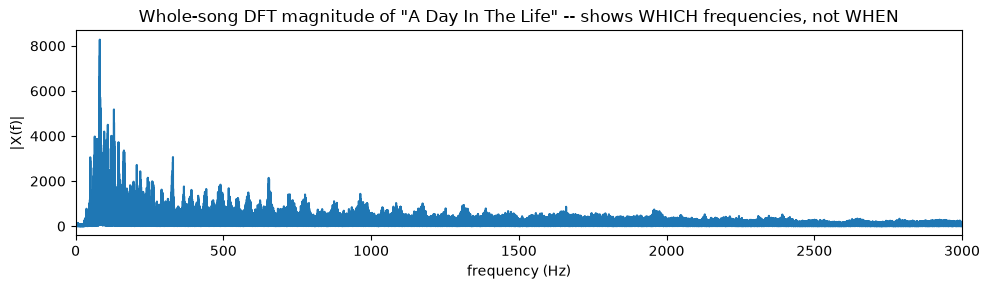

In [12]:
example_name = list(songs_audio.keys())[0]
example_audio = songs_audio[example_name]

X = np.fft.rfft(example_audio)
freqs = np.fft.rfftfreq(len(example_audio), d=1/SR)

plt.figure(figsize=(10,3))
plt.plot(freqs, np.abs(X))
plt.xlim(0, 3000)
plt.xlabel('frequency (Hz)'); plt.ylabel('|X(f)|')
plt.title(f'Whole-song DFT magnitude of "{example_name}" -- shows WHICH frequencies, not WHEN')
plt.tight_layout(); plt.show()

## Spectrogram: short window vs long window

Sliding a short window along the signal and taking its DFT at each position gives a
**spectrogram**, which is the frequency as a function of time. 

- **Short window:** good **time resolution** (we can tell exactly when a note starts/stops) but poor **frequency resolution** (narrow tones look blurred).
- **Long window:** good **frequency resolution** (narrow, precise frequency lines) but poor **time resolution** (note's on/off time is blurred).

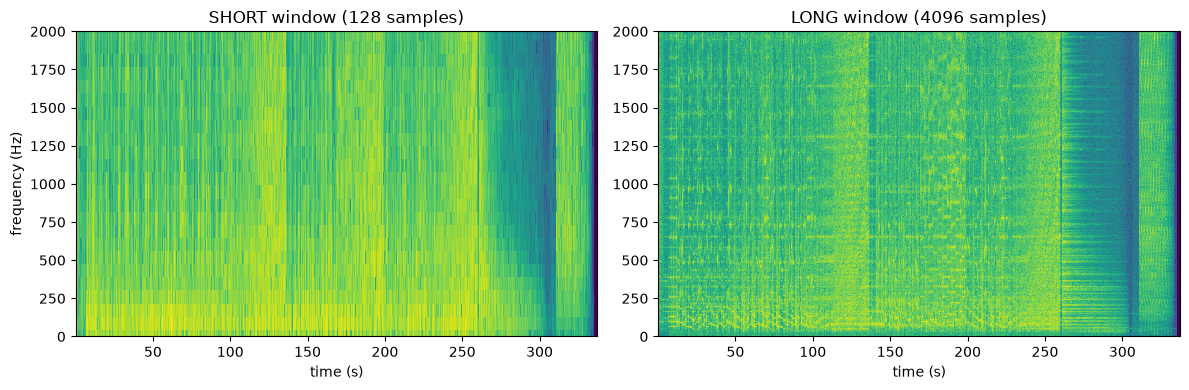

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
for ax, nperseg, label in zip(axes, [128, 4096], ["SHORT window (128 samples)", "LONG window (4096 samples)"]):
    f_spec, t_spec, Sxx = fp.spectrogram(example_audio, SR, nperseg=nperseg)
    ax.pcolormesh(t_spec, f_spec, 20*np.log10(Sxx+1e-9), shading='auto')
    ax.set_ylim(0, 2000)
    ax.set_title(label)
    ax.set_xlabel('time (s)')
axes[0].set_ylabel('frequency (Hz)')
plt.tight_layout(); plt.show()

## Building the fingerprint:

We keep only the **strongest local-maxima points** of the spectrogram (the "constellation"),
then pair nearby peaks into compact **hashes**: (f1, f2, delta t) two frequencies and the time gap between them, anchored at t1.

Found 6184 constellation peaks in 'A Day In The Life'


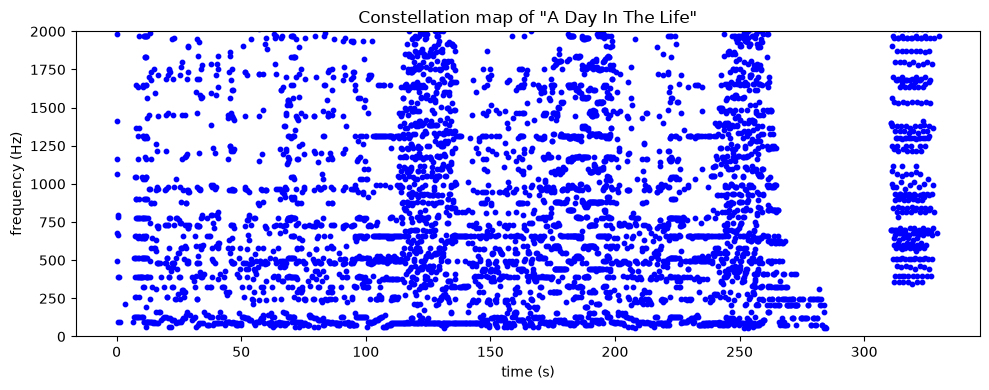

In [14]:
f_spec, t_spec, Sxx = fp.spectrogram(example_audio, SR, nperseg=1024)
peaks = fp.find_peaks_2d(Sxx)
print(f"Found {len(peaks)} constellation peaks in '{example_name}'")

plt.figure(figsize=(10,4))
#plt.pcolormesh(t_spec, f_spec, 20*np.log10(Sxx+1e-9), shading='auto', cmap='gray_r')
freq_idx = [p[0] for p in peaks]; time_idx = [p[1] for p in peaks]
plt.scatter(t_spec[time_idx], f_spec[freq_idx], c='blue', s=10)
plt.ylim(0, 2000)
plt.xlabel('time (s)'); plt.ylabel('frequency (Hz)')
plt.title(f'Constellation map of "{example_name}"')
plt.tight_layout(); plt.show()

## Indexing a song database, and matching a query

For each song we store every hash with its anchor time. To identify a query clip, we fingerprint
it the same way and, for each candidate song, build a **histogram of time offsets**
(`db_time - query_time`) at which its hashes match. A *true* match lines almost all matching
hashes up at a **single, consistent offset** (a tall, sharp peak in the histogram); a wrong song
only produces scattered, random offsets (a flat histogram).

Database built: 546673 unique hashes across 50 songs.
True source song : A Hard Day_s Night
Identified as     : A Hard Day_s Night


C:\Users\Gauri\AppData\Local\Temp\ipykernel_7396\1911260308.py:21: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.legend(); plt.tight_layout(); plt.show()


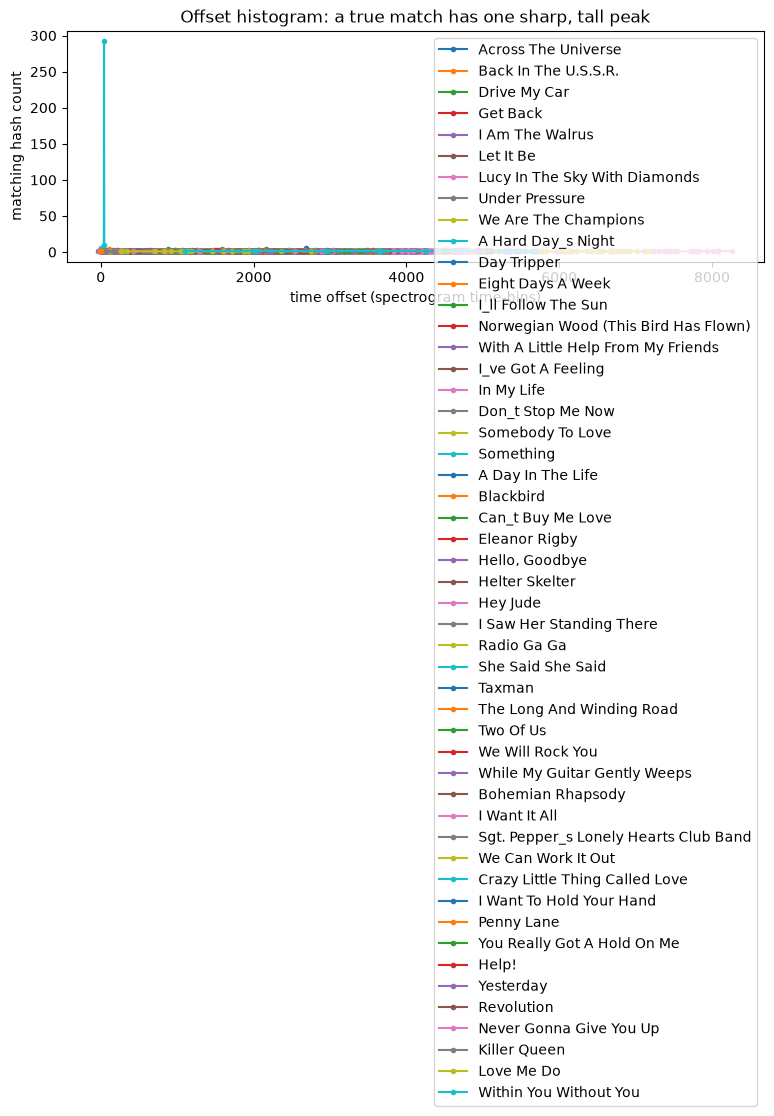

In [ ]:
songs_list = [(name, audio, SR) for name, audio in songs_audio.items()]
database = fp.build_database(songs_list, nperseg=1024, fan_out=5, use_pairs=True)
print(f"Database built: {len(database)} unique hashes across {len(songs_list)} songs.")

# Make a query: grab a short clip out of the middle of one song (simulating "a few
# seconds of audio recorded in a noisy cafe")
query_song = "song_beta" if "song_beta" in songs_audio else list(songs_audio.keys())[1]
query_clip = songs_audio[query_song][SR*2 : SR*4].copy()   # 2-second clip

best_match, offset_hist, q_peaks = fp.match_query(query_clip, SR, database, nperseg=1024, fan_out=5, use_pairs=True)
print(f"True source song : {query_song}")
print(f"Identified as     : {best_match}")

plt.figure(figsize=(9,3))
for name, hist in offset_hist.items():
    offsets = sorted(hist.keys())
    counts = [hist[o] for o in offsets]
    plt.plot(offsets, counts, marker='o', ms=3, label=name)
plt.xlabel('time offset (spectrogram time-bins)'); plt.ylabel('matching hash count')
plt.title('Offset histogram: (Sharp peaks indicate a true match)')
plt.legend(); plt.tight_layout(); plt.show()

## Single peaks vs Paired hashes 
A single peak's frequency is common. Different songs may contain a tone at roughly the same frequency, so single-peak "hashes" collide a lot between unrelated
songs.. A pair of peaks $(f_1, f_2, \Delta t)$ requires two unrelated tones to share
the same frequency pair *and* the same exact time gap. So the correct song's peak in the offset histogram stands out far more clearly above the rest.

In [16]:
db_single = fp.build_database(songs_list, nperseg=1024, use_pairs=False)
best_single, hist_single, _ = fp.match_query(query_clip, SR, db_single, nperseg=1024, use_pairs=False)

print("=== Paired hashes (f1, f2, dt) ===")
print({name: max(h.values()) for name, h in offset_hist.items()})
print("winner:", best_match)

print("\n=== Single-peak hashes (f1 only) ===")
print({name: max(h.values()) for name, h in hist_single.items()})
print("winner:", best_single)
print("\nNotice how much closer the single-peak scores are across songs --")
print("the margin between the true song and the runners-up is far smaller,")
print("making the decision much less reliable / more error-prone.")

=== Paired hashes (f1, f2, dt) ===
{'Across The Universe': 3, 'Back In The U.S.S.R.': 2, 'Drive My Car': 4, 'Get Back': 3, 'I Am The Walrus': 3, 'Let It Be': 3, 'Lucy In The Sky With Diamonds': 2, 'Under Pressure': 3, 'We Are The Champions': 2, 'A Hard Day_s Night': 292, 'Day Tripper': 2, 'Eight Days A Week': 4, 'I_ll Follow The Sun': 3, 'Norwegian Wood (This Bird Has Flown)': 2, 'With A Little Help From My Friends': 2, 'I_ve Got A Feeling': 3, 'In My Life': 2, 'Don_t Stop Me Now': 2, 'Somebody To Love': 2, 'Something': 1, 'A Day In The Life': 2, 'Blackbird': 2, 'Can_t Buy Me Love': 2, 'Eleanor Rigby': 3, 'Hello, Goodbye': 3, 'Helter Skelter': 3, 'Hey Jude': 2, 'I Saw Her Standing There': 3, 'Radio Ga Ga': 2, 'She Said She Said': 2, 'Taxman': 5, 'The Long And Winding Road': 1, 'Two Of Us': 4, 'We Will Rock You': 2, 'While My Guitar Gently Weeps': 2, 'Bohemian Rhapsody': 2, 'I Want It All': 3, 'Sgt. Pepper_s Lonely Hearts Club Band': 4, 'We Can Work It Out': 3, 'Crazy Little Thing Calle

## Robustness: added noise

We progressively add more noise (lower SNR) to the query clip and see how far recognition holds
up before it breaks.

In [17]:
print(f"{'SNR (dB)':>10} | {'matched song':<14} | {'winning score':>14}")
print("-"*45)
for snr in [40, 30, 20, 15, 10, 5, 0]:
    noisy_query = fp.add_noise(query_clip, snr_db=snr)
    best, hist, _ = fp.match_query(noisy_query, SR, database, nperseg=1024, fan_out=5, use_pairs=True)
    score = max(hist.get(best, {0:0}).values()) if best else 0
    print(f"{snr:>10} | {str(best):<14} | {score:>14}")

  SNR (dB) | matched song   |  winning score
---------------------------------------------
        40 | A Hard Day_s Night |            292
        30 | A Hard Day_s Night |            297
        20 | A Hard Day_s Night |            306
        15 | A Hard Day_s Night |            258
        10 | A Hard Day_s Night |            209
         5 | A Hard Day_s Night |            108
         0 | A Hard Day_s Night |             53


**Observation:** the matched song and its winning score stay essentially unchanged down to a
fairly noisy clip, then **collapse abruptly** once noise overwhelms the true spectral peaks (the
local-maxima detector starts mistaking noise-floor bumps for real peaks, both diluting the true
hashes and adding spurious ones). Recognition degrades **gracefully then suddenly fails**, rather
than failing gradually — a known characteristic of peak-based fingerprinting.

## Robustness: pitch shift / time stretch

A small pitch shift (here implemented as a simple resample, which changes pitch and tempo
together — the classic "speeding up a tape" effect) is tested next.

In [18]:
print("semitone shift\t| matched song\t| winning score")
for semis in [0, 0.25, 0.5, 1, 2, 4]:
    shifted_query = fp.pitch_shift_resample(query_clip, SR, semis)
    best, hist, _ = fp.match_query(shifted_query, SR, database, nperseg=1024, fan_out=5, use_pairs=True)
    score = max(hist.get(best, {0:0}).values()) if best else 0
    print(f"{semis}\t| {best}\t| {score}")

semitone shift	| matched song	| winning score
0	| A Hard Day_s Night	| 292
0.25	| A Hard Day_s Night	| 4
0.5	| Get Back	| 5
1	| Across The Universe	| 4
2	| Drive My Car	| 5
4	| Eleanor Rigby	| 5


**Why even a tiny pitch shift defeats the identifier, even though it still sounds the same
song to a human ear:** Hashes store **exact** frequency-bin indices. Shifting pitch moves
every frequency component to a new bin, so $(f_1, f_2, \Delta t)$ in the query almost never
**exactly** equals any hash stored in the database — even though the *relative* pattern of
peaks is nearly identical. Human hearing is comparatively insensitive to such
small uniform shifts, but a hash table built on exact integer bin indices has zero tolerance for it.

**A way to make the system more robust:** allow a small frequency tolerance when matching
hashes (e.g. quantize frequencies into coarser bins, or hash *ratios* between peak frequencies
instead of absolute values, since ratios are invariant to a uniform pitch multiplication) —
this trades fingerprint specificity for tolerance to small, uniform pitch/tempo changes.